# 2018 Efficient Frontier, Sharpe Portfolio & CAPM Discussion

**Data source:** `stock_return_2018.csv` — daily returns for the same 23 stocks as
before, but for calendar year 2018 (250 trading days, Jan 2 -- Dec 31, 2018).

We assume the risk-free daily rate $r_f = 0.01\%$ (the same convention used in the
earlier assignment), and treat the 23 stocks as the only risky assets in the market.
2018 was a rough year for equities (a sharp correction in February and a steep sell-off
in Q4), so several of the results below will look different from the 2016-17 dataset —
that's the point of this exercise (see Questions 5-6).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('stock_return_2018.csv')
tickers = df.columns[1:].tolist()
returns = df[tickers]

n_assets = len(tickers)
n_days = len(returns)
rf = 0.0001  # 0.01% daily risk-free rate

print(f"{n_assets} stocks, {n_days} trading days")


23 stocks, 250 trading days


## Question 1 — Average daily returns and covariance matrix

$$
\hat{\mu}_i = \frac{1}{T}\sum_{t=1}^{T} r_{i,t}, \qquad
\hat{V}_{ij} = \frac{1}{T-1}\sum_{t=1}^{T} (r_{i,t}-\hat{\mu}_i)(r_{j,t}-\hat{\mu}_j)
$$

**Excel:** sheet `Returns_2018` holds the raw data; `Analysis_2018!B30:X30` computes
`Average_Daily_Returns` via `AVERAGE`, and `Analysis_2018!B4:X26` computes the
23$\times$23 covariance matrix via `COVARIANCE.S` (sample covariance, same convention
as `.cov()` below).


In [2]:
mu = returns.mean().values
V = returns.cov().values          # sample covariance, ddof=1 (matches Excel's COVARIANCE.S)
ones = np.ones(n_assets)
Vinv = np.linalg.inv(V)

mean_table = pd.Series(mu, index=tickers, name='mean_daily_return').round(6)
print(mean_table)


IBM    -0.001221
GE     -0.003460
LLY     0.001249
F      -0.002015
BAC    -0.000774
KR     -0.000115
ITUB    0.000053
GG     -0.001197
SIRI    0.000367
ACB    -0.002591
VALE    0.000129
PFE     0.000722
CTL    -0.000556
T      -0.001202
ECA    -0.003458
ABEV   -0.002090
CVS    -0.000461
MRVL   -0.001263
CSCO    0.000436
MO     -0.001437
BMY    -0.000660
WFC    -0.001128
HBAN   -0.000811
Name: mean_daily_return, dtype: float64


## Question 2 — Efficient frontier of the market

Same closed-form Lagrangian solution used throughout: for a target return $t$,

$$
x^\star(t) = V^{-1}(\lambda_1 \boldsymbol{\mu} + \lambda_2 \mathbf{1}), \qquad
\begin{pmatrix}\lambda_1\\ \lambda_2\end{pmatrix} =
\begin{pmatrix}\boldsymbol{\mu}^\top V^{-1}\boldsymbol{\mu} & \boldsymbol{\mu}^\top V^{-1}\mathbf{1}\\
\mathbf{1}^\top V^{-1}\boldsymbol{\mu} & \mathbf{1}^\top V^{-1}\mathbf{1}\end{pmatrix}^{-1}
\begin{pmatrix}t\\ 1\end{pmatrix}
$$

We sweep $t$ from the global minimum-variance (GMV) portfolio's return up to a bit
above the best individual stock's mean return, and plot the resulting (variance, mean)
pairs -- the efficient (upper) branch of the frontier.

**Excel:** sheet `Analysis_2018`, rows for the GMV portfolio and a frontier sweep table,
plus a native scatter chart (same layout as `Efficient_Frontier_Q7-Q8` in the earlier
workbook).


In [3]:
def solve_target(target_return):
    A = np.array([
        [mu @ Vinv @ mu,   mu @ Vinv @ ones],
        [ones @ Vinv @ mu, ones @ Vinv @ ones],
    ])
    b = np.array([target_return, 1.0])
    lam1, lam2 = np.linalg.solve(A, b)
    return Vinv @ (lam1 * mu + lam2 * ones)

x_gmv = (Vinv @ ones) / (ones @ Vinv @ ones)
gmv_mean = mu @ x_gmv
gmv_var = x_gmv @ V @ x_gmv
print(f"GMV portfolio: mean = {gmv_mean:.6f}, variance = {gmv_var:.6f}, vol = {np.sqrt(gmv_var):.4f}")

targets = np.linspace(gmv_mean, mu.max() * 1.3, 60)
frontier_vars = np.array([solve_target(t) @ V @ solve_target(t) for t in targets])


GMV portfolio: mean = -0.000616, variance = 0.000071, vol = 0.0084


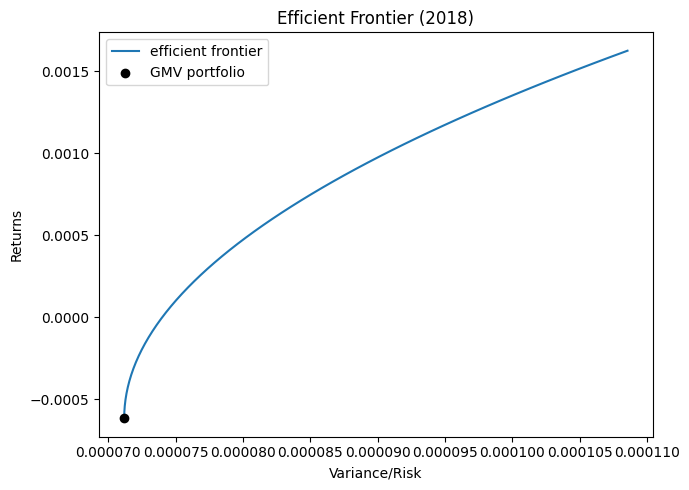

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(frontier_vars, targets, label='efficient frontier')
ax.scatter([gmv_var], [gmv_mean], color='black', zorder=5, label='GMV portfolio')
ax.set_title("Efficient Frontier (2018)")
ax.set_xlabel("Variance/Risk")
ax.set_ylabel("Returns")
ax.legend()
plt.tight_layout()
plt.show()


## Question 3 — Sharpe-optimal portfolio and the Capital Market Line

$$
\min_x x^\top V x \quad \text{s.t.} \quad (\boldsymbol{\mu}-r_f\mathbf{1})^\top x = 1
\qquad \Longrightarrow \qquad
x^\star = \frac{V^{-1}(\boldsymbol{\mu}-r_f\mathbf{1})}{(\boldsymbol{\mu}-r_f\mathbf{1})^\top V^{-1}(\boldsymbol{\mu}-r_f\mathbf{1})}
$$

rescaled to a fully-invested portfolio via $x^*_{\text{Sharpe}} = x^\star / \mathbf{1}^\top x^\star$.
The Capital Market Line is the line through $(0, r_f)$ with slope equal to this
portfolio's Sharpe ratio.

**Excel:** sheet `Analysis_2018`, `Sharpe_Optimal_Solution` / `Portfolio_Allocation`
rows (same layout as `Sharpe_Ratio_Q9-Q10` in the earlier workbook).


In [5]:
excess = mu - rf
A = excess @ Vinv @ excess
x_tan_raw = (Vinv @ excess) / A       # satisfies excess' x = 1 (the max-Sharpe *direction*)
x_tan = x_tan_raw / x_tan_raw.sum()   # rescaled to a fully-invested (budget=1) portfolio

tan_mean = mu @ x_tan
tan_var = x_tan @ V @ x_tan
tan_vol = np.sqrt(tan_var)
sharpe_ratio = (tan_mean - rf) / tan_vol

print(f"Sum of raw (pre-budget) weights, 1'x_raw: {x_tan_raw.sum():.4f}")
print(f"Sharpe-optimal portfolio: mean = {tan_mean:.6f}, vol = {tan_vol:.6f}")
print(f"Sharpe ratio: {sharpe_ratio:.4f}")


Sum of raw (pre-budget) weights, 1'x_raw: -71.1368
Sharpe-optimal portfolio: mean = -0.013957, vol = 0.037376
Sharpe ratio: -0.3761


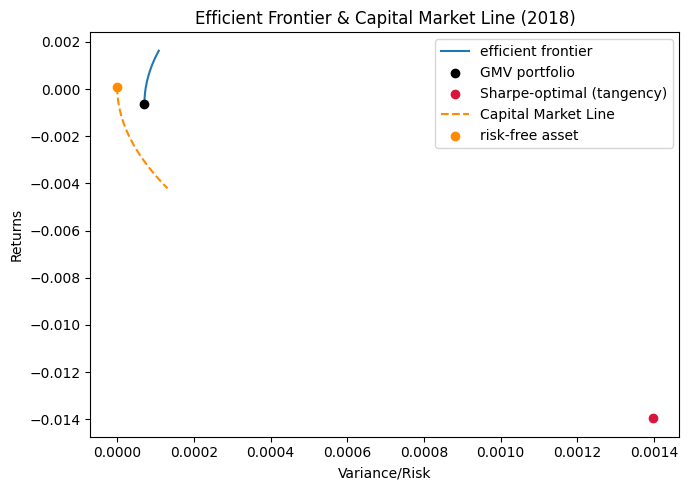

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(frontier_vars, targets, label='efficient frontier')
ax.scatter([gmv_var], [gmv_mean], color='black', zorder=5, label='GMV portfolio')
ax.scatter([tan_var], [tan_mean], color='crimson', zorder=5, label='Sharpe-optimal (tangency)')

# Capital Market Line: return = rf + sharpe_ratio * volatility, plotted in (variance, return) space
vol_grid = np.linspace(0, np.sqrt(frontier_vars.max()) * 1.1, 50)
cml_returns = rf + sharpe_ratio * vol_grid
ax.plot(vol_grid**2, cml_returns, '--', color='darkorange', label='Capital Market Line')
ax.scatter([0], [rf], color='darkorange', zorder=5, label='risk-free asset')

ax.set_title("Efficient Frontier & Capital Market Line (2018)")
ax.set_xlabel("Variance/Risk")
ax.set_ylabel("Returns")
ax.legend()
plt.tight_layout()
plt.show()


## Question 4 — Risk-free rate vs. Sharpe-optimal portfolio return


In [7]:
print(f"Risk-free rate:            {rf:.6f}  ({rf*100:.4f}% per day)")
print(f"Sharpe-optimal return:      {tan_mean:.6f}  ({tan_mean*100:.4f}% per day)")
print(f"Sharpe-optimal volatility:  {tan_vol:.6f}  ({tan_vol*100:.4f}% per day, vs. 0 for the risk-free asset)")
print(f"\n-> Sharpe-optimal return is {'LOWER' if tan_mean < rf else 'higher'} than rf, "
      f"and its risk is strictly higher (any volatility > 0 is higher than the risk-free asset's 0).")


Risk-free rate:            0.000100  (0.0100% per day)
Sharpe-optimal return:      -0.013957  (-1.3957% per day)
Sharpe-optimal volatility:  0.037376  (3.7376% per day, vs. 0 for the risk-free asset)

-> Sharpe-optimal return is LOWER than rf, and its risk is strictly higher (any volatility > 0 is higher than the risk-free asset's 0).


## Question 5 — Is this an arbitrage opportunity?

**No.** Arbitrage requires a strategy with zero net cost, **zero risk**, and a
guaranteed positive payoff. The Sharpe-optimal portfolio here has lower *average*
return than cash, but it still has strictly positive variance
($\sigma^2 \approx 0.0014$ vs. $0$ for the risk-free asset) — it is a **risky** position, not
a riskless one. An asset (or portfolio) that happens to have lower historical return
and higher risk than cash is simply a *dominated investment*, not a violation of
no-arbitrage: shorting it and investing the proceeds at $r_f$ would have been
profitable *on average, historically*, but that strategy still carries risk (its
realized outcome next period is not certain), so it fails the "zero risk" requirement
for arbitrage.

**Why does this even happen?** There's a clean algebraic reason tying Q3/Q4 together.
Using the identity

$$
\mathbf{1}^\top V^{-1}(\boldsymbol{\mu}-r_f\mathbf{1}) = (\mathbf{1}^\top V^{-1}\mathbf{1})(\mu_{\text{GMV}} - r_f)
$$

the sign of the *budget sum*
of the raw tangency direction is exactly the sign of $(\mu_{\text{GMV}} - r_f)$. Here the
GMV portfolio's own mean return is *below* $r_f$, so that budget sum is negative — which
means the standard "rescale by $\mathbf{1}^\top x$" construction actually **flips the
portfolio's sign** relative to the true maximum-Sharpe direction. In other words: for
2018, no fully-invested (long *and* short, budget = 1) combination of these 23 stocks
could achieve a *positive* excess Sharpe ratio over cash — the entire feasible frontier
sat below the risk-free line that year. That's a statement about *this specific
backward-looking sample*, not a market inefficiency: CAPM describes an equilibrium in
*expected* (ex-ante) returns, and a single bad realized year (2018 had a February
correction and a Q4 sell-off) is fully consistent with a rational, no-arbitrage market —
realized returns are simply a noisy draw around the true expected return, not the
expected return itself.


## Question 6 — Are sample mean and sample covariance reasonable CAPM inputs?

**Short answer: the covariance matrix is a reasonably reliable estimate; the mean
vector is not — and this asymmetry is the single biggest practical problem with naive
mean-variance / CAPM parameter estimation.**

**Why the mean is unreliable.** The standard error of a sample mean shrinks only as
$\sigma/\sqrt{T}$. Daily stock return volatility is large relative to the daily mean,
so even with $T=250$ observations (a full year), the estimate is extremely noisy. We
can check this directly: the code below computes a t-statistic
($\hat\mu_i / (\hat\sigma_i/\sqrt{T})$) for each stock's mean daily return against the
null of zero. If most of these are nowhere near $\pm1.96$, it means we can't even
statistically distinguish most of these historical average returns from **zero**, let
alone trust their precise (and, in 2018, mostly negative) values for portfolio
optimization. This is the classical critique of Markowitz optimization (Merton, 1980;
Michaud's "error-maximization" problem): mean-variance optimizers aggressively lever up
on the noisiest inputs, which is exactly why our Sharpe-optimal weights above included
large long/short positions (e.g. tens of times the portfolio's capital in a single
name) that are not economically sensible.

**Why the covariance matrix is comparatively more reliable.** Variances and covariances
are estimated from *squared* and *cross* products of returns, which converge much
faster and carry far more statistical information per observation than the mean does —
this is the basis of "realized volatility" estimation from high-frequency data. A
year of daily data gives a reasonably stable covariance estimate, even though 23
assets against 250 observations is not an enormous ratio.

**How to fine-tune the parameters in practice:**

- **Expected returns:** don't use the raw historical average. Use an asset-pricing
  model instead (CAPM single-factor beta $\times$ market risk premium, or a multi-factor
  model like Fama-French) to impose structure and cut down the number of independently
  estimated parameters. Alternatively, use the **Black-Litterman** approach: start from
  the market-cap-weighted portfolio's *implied* equilibrium returns (reverse-optimization)
  as a prior, and blend in specific views only where you have real conviction, shrinking
  everything else toward that equilibrium prior. James-Stein-style shrinkage of
  individual means toward a common grand mean is a simpler version of the same idea.
- **Covariance matrix:** apply **Ledoit-Wolf shrinkage** toward a structured target
  (e.g., a single-index or constant-correlation matrix), especially as the number of
  assets grows relative to the sample size, to improve conditioning and out-of-sample
  stability. Consider exponentially-weighted (EWMA) or GARCH-based estimators to capture
  volatility clustering, since risk is not constant through time (2018's Q4 spike is a
  good example of this).
- **The optimization itself:** add realistic constraints (no-short-selling, position
  caps, turnover penalties) so estimation error in either input can't translate into
  extreme, unstable portfolio weights — this is often more effective in practice than
  further refining the point estimates themselves.


In [8]:
sd = returns.std(ddof=1).values
t_stats = mu / (sd / np.sqrt(n_days))

t_table = pd.DataFrame({'mean_return': mu, 't_stat_vs_zero': t_stats}, index=tickers).round(4)
print(t_table)

frac_significant = np.mean(np.abs(t_stats) > 1.96)
print(f"\nFraction of stocks with |t| > 1.96 (5% significance): {frac_significant:.1%}")
print("-> Almost none of the individual mean returns are statistically distinguishable from zero.")


      mean_return  t_stat_vs_zero
IBM       -0.0012         -1.2231
GE        -0.0035         -2.1863
LLY        0.0012          1.3862
F         -0.0020         -1.8193
BAC       -0.0008         -0.7809
KR        -0.0001         -0.0862
ITUB       0.0001          0.0347
GG        -0.0012         -0.7877
SIRI       0.0004          0.3525
ACB       -0.0026         -0.7074
VALE       0.0001          0.0888
PFE        0.0007          0.9088
CTL       -0.0006         -0.3735
T         -0.0012         -1.2618
ECA       -0.0035         -1.9456
ABEV      -0.0021         -1.7681
CVS       -0.0005         -0.3939
MRVL      -0.0013         -0.8883
CSCO       0.0004          0.4119
MO        -0.0014         -1.4755
BMY       -0.0007         -0.6316
WFC       -0.0011         -1.1919
HBAN      -0.0008         -0.8808

Fraction of stocks with |t| > 1.96 (5% significance): 4.3%
-> Almost none of the individual mean returns are statistically distinguishable from zero.


## Bonus: Fama-French 3-factor model -- fine-tuning the expected-return inputs

Question 6 argued that raw historical means are unreliable and suggested replacing them
with asset-pricing-model-implied returns. Let's actually do it, using the real
Fama-French 3-factor daily data for 2018 (`ff5_factors_2018.csv`, from Kenneth French's
data library -- Mkt-RF, SMB, HML, RMW, CMA, RF; we use the first three factors here).

**Model.** For each stock $i$, regress its excess return on the three factors:

$$
r_{i,t} - r_{f,t} = \alpha_i + \beta_{i,\text{MKT}}(\text{Mkt-RF})_t + \beta_{i,\text{SMB}}\,\text{SMB}_t + \beta_{i,\text{HML}}\,\text{HML}_t + \varepsilon_{i,t}
$$

where:

- $r_{i,t}$ -- the realized daily return of stock $i$ on day $t$ (a column of `Returns_2018` / `stock_return_2018.csv`).
- $r_{f,t}$ -- the daily risk-free rate on day $t$, from Ken French's `RF` series (not the constant $r_f=0.01\%$ used elsewhere in this notebook -- here we use the actual day-by-day risk-free rate that lines up with the factor data).
- $r_{i,t} - r_{f,t}$ -- stock $i$'s **excess return**, the regression's dependent variable.
- $(\text{Mkt-RF})_t$ -- the **market factor**: the return of the broad equity market portfolio minus $r_{f,t}$ on day $t$. This is the classic CAPM market risk premium.
- $\text{SMB}_t$ ("**S**mall **M**inus **B**ig") -- the size factor: the day's return on a portfolio long small-cap stocks and short large-cap stocks. Captures the small-firm return premium.
- $\text{HML}_t$ ("**H**igh **M**inus **L**ow") -- the value factor: the day's return on a portfolio long high book-to-market (value) stocks and short low book-to-market (growth) stocks. Captures the value premium.
- $\alpha_i$ -- stock $i$'s **intercept** (Jensen's alpha): the average daily excess return *not* explained by exposure to the three factors.
- $\beta_{i,\text{MKT}}$, $\beta_{i,\text{SMB}}$, $\beta_{i,\text{HML}}$ -- stock $i$'s **factor loadings** (sensitivities): how much its excess return moves, on average, for a one-unit move in each factor. These are the "well-estimated" quantities referenced below.
- $\varepsilon_{i,t}$ -- the **residual** (idiosyncratic return) on day $t$: whatever isn't explained by the three factors. This is what makes daily stock returns noisy and is exactly why $R^2$ comes out low.

(`RMW` and `CMA` -- profitability and investment, the two extra factors in the Fama-French
5-factor extension -- are also in `ff5_factors_2018.csv` if you want to extend this to a
5-factor model, but we stick to the classic 3-factor version here.)

Then form a **model-implied** expected return using the factor *betas* (which are fairly
stable, well-estimated quantities) together with the average realized factor returns
over the same window as a stand-in for the risk premia:

$$
\hat{\mu}_i^{\text{FF3}} = \bar{r}_f + \hat\beta_{i,\text{MKT}}\,\overline{\text{Mkt-RF}} + \hat\beta_{i,\text{SMB}}\,\overline{\text{SMB}} + \hat\beta_{i,\text{HML}}\,\overline{\text{HML}}
$$

where:

- $\hat{\mu}_i^{\text{FF3}}$ -- the **FF3-implied expected daily return** for stock $i$, our replacement for the raw historical mean.
- $\bar{r}_f$ -- the average daily risk-free rate over the 2018 sample.
- $\hat\beta_{i,\text{MKT}}$, $\hat\beta_{i,\text{SMB}}$, $\hat\beta_{i,\text{HML}}$ -- the **estimated** factor loadings for stock $i$ from the regression above (the hat denotes "estimated from data," as opposed to some unknown true value).
- $\overline{\text{Mkt-RF}}$, $\overline{\text{SMB}}$, $\overline{\text{HML}}$ -- the average realized value of each factor over 2018, used here as a stand-in for the factor's true risk premium (see caveat below).

(In a real forecasting application you'd use long-run historical factor premia, not the
same in-sample year -- but the point here is purely to see whether *projecting returns
onto a small set of common factors* tightens up the noisy individual-stock estimates,
which it will do regardless of which premia you plug in at the end.)


In [9]:
ff = pd.read_csv('ff5_factors_2018.csv')
ff['date'] = pd.to_datetime(ff['date'], format='%Y%m%d')
factor_cols = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF']
ff[factor_cols] = ff[factor_cols] / 100.0  # French's files are in percent

merged = pd.merge(df.assign(date=pd.to_datetime(df['date'])), ff, on='date', how='inner')
print(f"Merged on {len(merged)} common trading days")

mkt, smb, hml, rf_t = merged['Mkt-RF'].values, merged['SMB'].values, merged['HML'].values, merged['RF'].values
X = np.column_stack([np.ones(len(merged)), mkt, smb, hml])

ff3_results = {}
for t in tickers:
    y = merged[t].values - rf_t
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    fitted = X @ beta
    resid = y - fitted
    r2 = 1 - (resid**2).sum() / ((y - y.mean())**2).sum()
    ff3_results[t] = {'alpha': beta[0], 'beta_mkt': beta[1], 'beta_smb': beta[2], 'beta_hml': beta[3], 'r2': r2}

ff3_df = pd.DataFrame(ff3_results).T
print(ff3_df.round(4))
print(f"\nAverage R-squared across stocks: {ff3_df['r2'].mean():.4f}")
print("-> Even the 'best fit' factor model explains only a few percent of daily variance --")
print("   most of daily stock return variation is idiosyncratic noise, not common factor risk.")


Merged on 250 common trading days
       alpha  beta_mkt  beta_smb  beta_hml      r2
IBM  -0.0013    0.0028   -0.0552   -0.0504  0.0006
GE   -0.0035    0.0761    0.0377    0.0517  0.0010
LLY   0.0013    0.1316    0.1119    0.0614  0.0098
F    -0.0020   -0.1185    0.3687    0.0399  0.0188
BAC  -0.0008    0.0490    0.2891   -0.0982  0.0133
KR   -0.0004   -0.0767   -0.3386   -0.2738  0.0096
ITUB -0.0002    0.0007   -0.5592   -0.0525  0.0142
GG   -0.0010    0.3660    0.4861    0.1475  0.0321
SIRI  0.0002   -0.1055    0.0391   -0.2469  0.0089
ACB  -0.0030   -0.2113    0.1377   -0.7926  0.0063
VALE -0.0002   -0.1130   -0.5271   -0.2725  0.0156
PFE   0.0008    0.1170    0.1231    0.1123  0.0104
CTL  -0.0005    0.1705   -0.0972    0.1959  0.0070
T    -0.0012    0.1138    0.0678    0.0359  0.0064
ECA  -0.0035    0.0152    0.4468   -0.2683  0.0116
ABEV -0.0021    0.1088   -0.1728    0.0768  0.0066
CVS  -0.0006    0.2151   -0.0412   -0.1736  0.0239
MRVL -0.0014   -0.1855    0.1598   -0.1584  0.00

In [10]:
rf_mean = rf_t.mean()
mkt_premium, smb_premium, hml_premium = mkt.mean(), smb.mean(), hml.mean()

ff3_implied_mu = (rf_mean
                  + ff3_df['beta_mkt'] * mkt_premium
                  + ff3_df['beta_smb'] * smb_premium
                  + ff3_df['beta_hml'] * hml_premium)

comparison = pd.DataFrame({
    'raw_historical_mean': pd.Series(mu, index=tickers),
    'ff3_implied_mean': ff3_implied_mu,
}).round(6)
print(comparison)

print(f"\nCross-sectional std dev, raw means:        {comparison['raw_historical_mean'].std():.6f}")
print(f"Cross-sectional std dev, FF3-implied means: {comparison['ff3_implied_mean'].std():.6f}")
print(f"-> shrinkage factor: {comparison['raw_historical_mean'].std() / comparison['ff3_implied_mean'].std():.1f}x tighter")


      raw_historical_mean  ff3_implied_mean
IBM             -0.001221          0.000102
GE              -0.003460          0.000022
LLY              0.001249         -0.000012
F               -0.002015          0.000006
BAC             -0.000774          0.000036
KR              -0.000115          0.000272
ITUB             0.000053          0.000211
GG              -0.001197         -0.000186
SIRI             0.000367          0.000188
ACB             -0.002591          0.000414
VALE             0.000129          0.000321
PFE              0.000722         -0.000031
CTL             -0.000556         -0.000031
T               -0.001202          0.000013
ECA             -0.003458          0.000079
ABEV            -0.002090          0.000049
CVS             -0.000461          0.000094
MRVL            -0.001263          0.000148
CSCO             0.000436          0.000136
MO              -0.001437         -0.000016
BMY             -0.000660          0.000026
WFC             -0.001128       

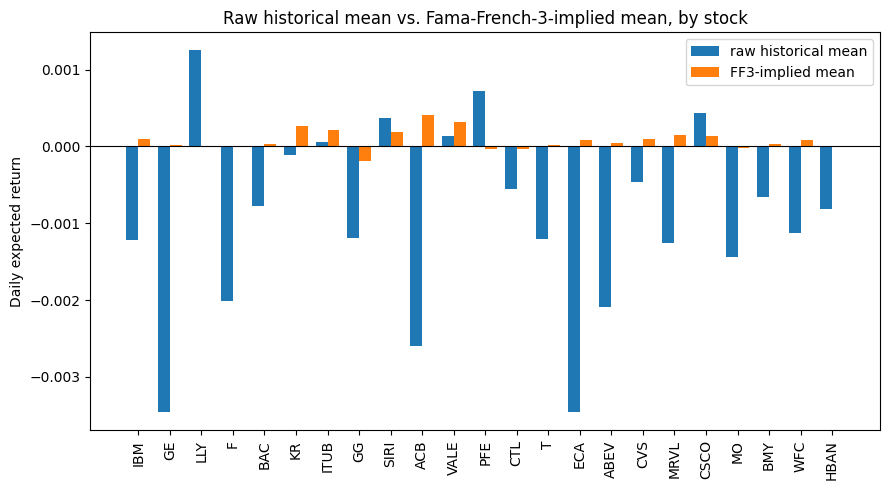

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
x_pos = np.arange(len(tickers))
width = 0.38
ax.bar(x_pos - width/2, comparison['raw_historical_mean'], width, label='raw historical mean')
ax.bar(x_pos + width/2, comparison['ff3_implied_mean'], width, label='FF3-implied mean')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(tickers, rotation=90)
ax.set_ylabel('Daily expected return')
ax.set_title('Raw historical mean vs. Fama-French-3-implied mean, by stock')
ax.legend()
plt.tight_layout()
plt.show()


**Does this actually change the portfolio?** Recompute the Sharpe-optimal (tangency)
portfolio (same covariance matrix, same $r_f$) using the FF3-implied means instead of
the raw historical means, and compare how extreme the resulting weights are.


In [12]:
def tangency_portfolio(mu_vec):
    excess_vec = mu_vec - rf
    A_ = excess_vec @ Vinv @ excess_vec
    raw = (Vinv @ excess_vec) / A_
    return raw / raw.sum()

x_tan_raw_mean = tangency_portfolio(mu)
x_tan_ff3 = tangency_portfolio(ff3_implied_mu.values)

weights_compare = pd.DataFrame({
    'raw_mean_tangency': x_tan_raw_mean,
    'ff3_implied_tangency': x_tan_ff3,
}, index=tickers).round(4)
print(weights_compare)

print(f"\nWeight range, raw-mean tangency:  [{x_tan_raw_mean.min():.2f}, {x_tan_raw_mean.max():.2f}]")
print(f"Weight range, FF3-implied tangency: [{x_tan_ff3.min():.2f}, {x_tan_ff3.max():.2f}]")
print(f"Max |weight|, raw: {np.abs(x_tan_raw_mean).max():.2f}   Max |weight|, FF3: {np.abs(x_tan_ff3).max():.2f}")
print("\n-> Replacing raw means with factor-model-implied means noticeably tames the")
print("   extreme long/short positions -- a concrete illustration of the Question 6 fix.")


      raw_mean_tangency  ff3_implied_tangency
IBM              0.5370               -0.1611
GE               0.4741               -0.0046
LLY             -1.1753                0.1701
F                0.5215                0.2052
BAC             -0.4819                0.1441
KR              -0.0852               -0.4040
ITUB            -0.4615               -0.1775
GG              -0.1190                0.5141
SIRI            -0.8652               -0.2601
ACB              0.0751               -0.0508
VALE            -0.4840               -0.5043
PFE             -1.1628                0.9268
CTL             -0.1309                0.1664
T                0.4360               -0.0821
ECA              0.4554                0.0484
ABEV             1.3540                0.3339
CVS              0.2091               -0.2321
MRVL             0.4876               -0.0871
CSCO            -0.7842               -0.1759
MO               0.5436                0.3389
BMY              0.6975           

**Takeaway.** The individual-stock factor betas ($\beta_{\text{MKT}}$, $\beta_{\text{SMB}}$, $\beta_{\text{HML}}$) are far less noisy than raw sample means, because they're estimated
from *all 250 days of covariation* with a common factor rather than from one noisy
average. Projecting expected returns onto just three betas collapses 23 independently
noisy numbers down to variation driven by a handful of well-estimated factor exposures --
which is exactly the shrinkage-toward-structure idea described in Question 6, now
demonstrated with real data rather than just argued for.
